In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
xlsx_path = "../../../data/processed/clinical/Subjects_data.xlsx"
df = pd.read_excel(xlsx_path)
df.columns = df.columns.str.strip()

In [3]:
df.columns

Index(['S_RECORD_id', 'Date_start_HDM', 'DCABP_first_month', 'DCABP_general',
       'Hyper_DCABP_month_1', 'Hyper_DCABP_general', 'DCABP_switch',
       'Withdrawal', 'Exitus', 'PD_event', 'Obs_time', 'Early_PD', 'Cohort',
       'Treatment_group', 'Age', 'Ethnicity', 'Height', 'Weight', 'BMI',
       'Menopause', 'ECOG', 'Hemoglobin_g_per_dL',
       'Linfocytes_thousands_per_mm3', 'Neutrophils_thousands_per_mm3',
       'Platelets_thousands_per_mm3', 'Albumin_g_per_dL', 'Corticoids',
       'Beta_blockers', 'Opioids'],
      dtype='object')

Using topic column (F) -> DCABP_general
Using age column   (P) -> Age
N total rows: 178
Missing topic: 14 | Missing age: 1
N used for Age×Topic plots: 164

Contingency table (counts):
topic         0.0  1.0  2.0  3.0  4.0  5.0
age_tertile                               
T1 (younger)    3    8   27    7   12    1
T2              5   12   10    8   15    9
T3 (older)     10    7    4    5    8   13


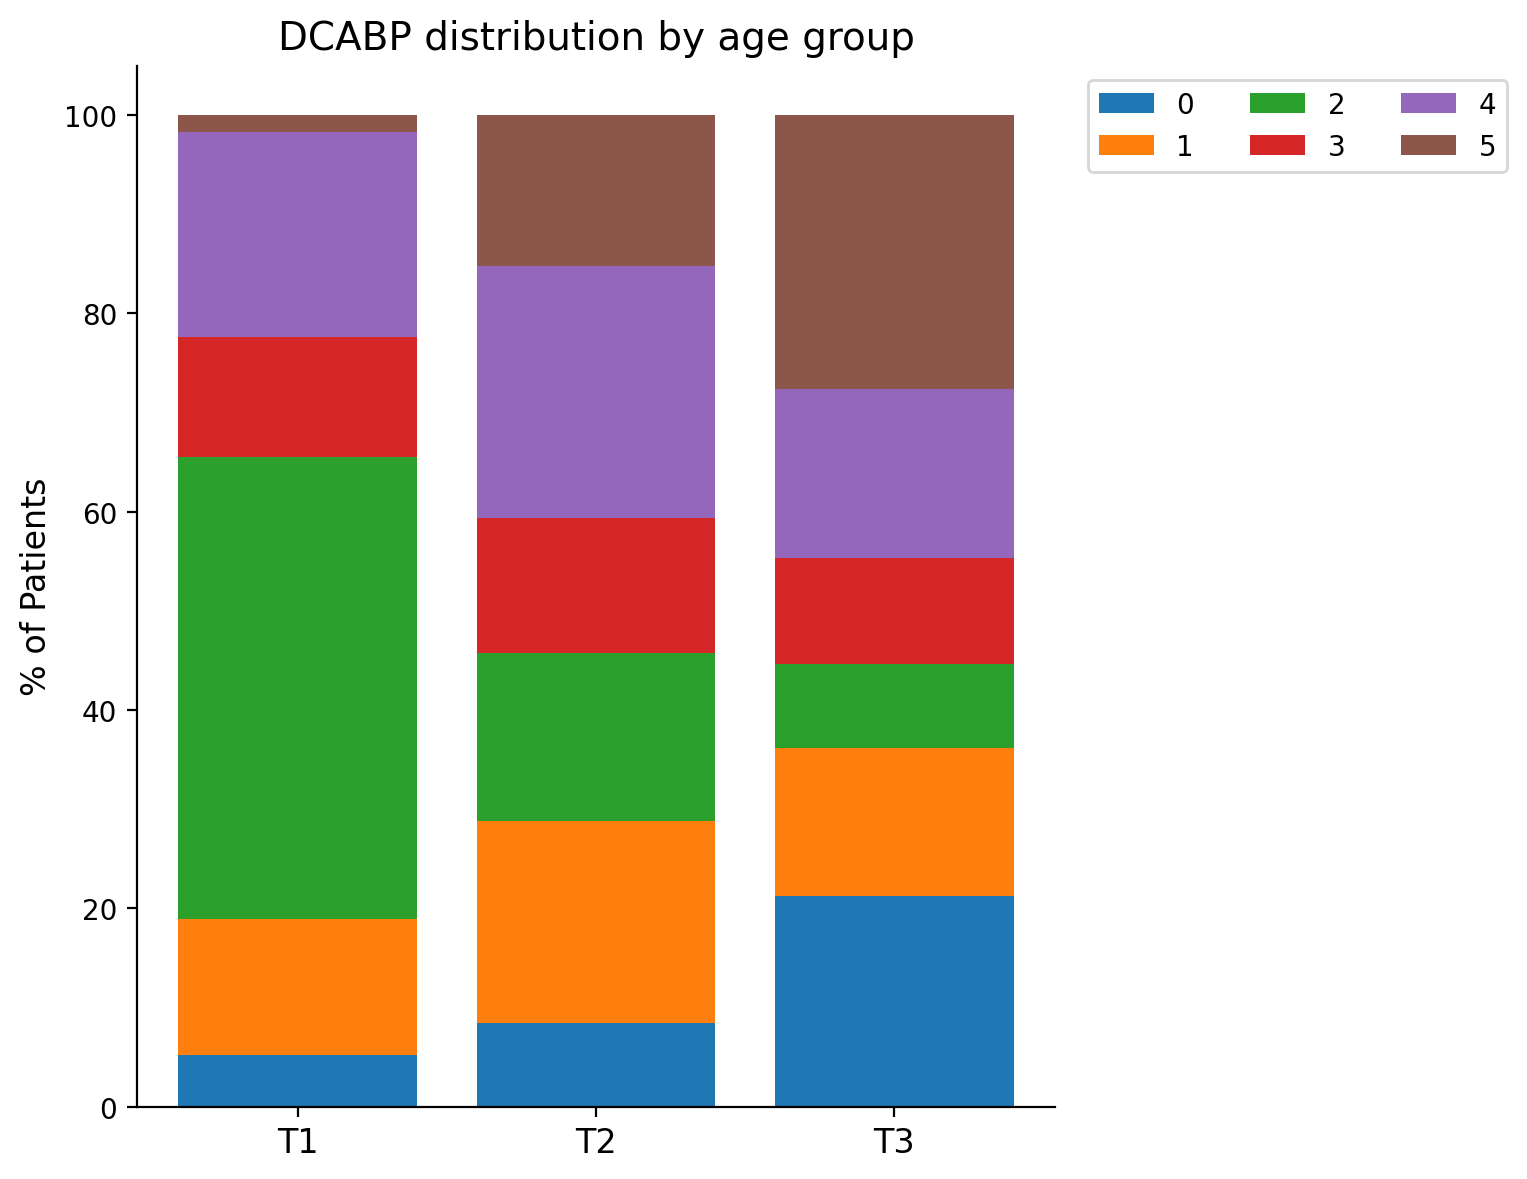

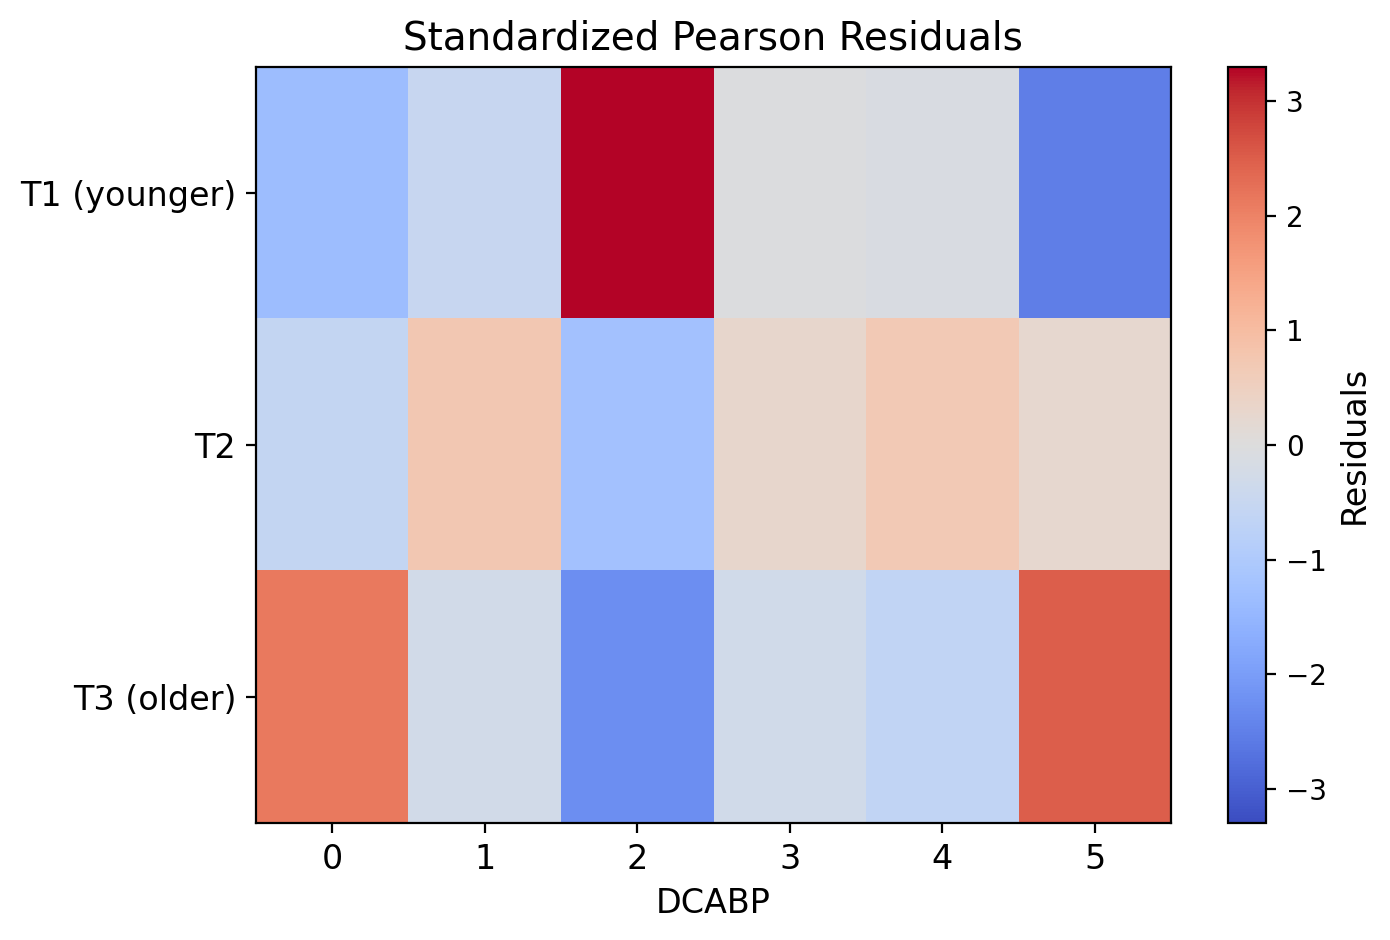

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import math
 
# -----------------------
# Helpers
# -----------------------
def excel_col_to_idx(col_letter: str) -> int:
    col_letter = col_letter.upper().strip()
    idx = 0
    for ch in col_letter:
        idx = idx * 26 + (ord(ch) - ord('A') + 1)
    return idx - 1
 
def clean_topic_series(s):
    return pd.to_numeric(s, errors="coerce")
 
def clean_age_series(s):
    return pd.to_numeric(s, errors="coerce")
 
# -----------------------
# Inputs (EDIT THIS)
# -----------------------
INPUT_XLSX = "../../../data/processed/clinical/Subjects_data.xlsx"  # tu base consolidada con topics
 
TOPIC_COL_LETTER = "F"   # topic_all
AGE_COL_LETTER   = "P"   # age
 
OUT_PREFIX = "Fig_AgeTertile_by_Topic"
 
# -----------------------
# Load
# -----------------------
df = pd.read_excel(INPUT_XLSX)
df.columns = [str(c).strip() for c in df.columns]
 
topic_col = 'DCABP_general'
age_col   = 'Age'
 
print(f"Using topic column ({TOPIC_COL_LETTER}) -> {topic_col}")
print(f"Using age column   ({AGE_COL_LETTER}) -> {age_col}")
 
tmp = df[[topic_col, age_col]].copy()
tmp["topic"] = clean_topic_series(tmp[topic_col])
tmp["age"]   = clean_age_series(tmp[age_col])
 
# Drop missing age or topic
n_total = len(tmp)
n_missing_topic = tmp["topic"].isna().sum()
n_missing_age = tmp["age"].isna().sum()
 
tmp2 = tmp.dropna(subset=["topic", "age"]).copy()
 
print(f"N total rows: {n_total}")
print(f"Missing topic: {n_missing_topic} | Missing age: {n_missing_age}")
print(f"N used for Age×Topic plots: {len(tmp2)}")
 
# -----------------------
# Age tertiles
# -----------------------
# qcut makes equal-sized tertiles (as much as possible)
tmp2["age_tertile"] = pd.qcut(tmp2["age"], q=3, labels=["T1 (younger)", "T2", "T3 (older)"])
 
age_order = ["T1 (younger)", "T2", "T3 (older)"]
topic_levels = sorted(tmp2["topic"].unique())
 
# Contingency table
counts = pd.crosstab(tmp2["age_tertile"], tmp2["topic"]).reindex(index=age_order, columns=topic_levels, fill_value=0)
print("\nContingency table (counts):")
print(counts)
 
# -----------------------
# 1) Stacked bars (% within age tertile)
# -----------------------
props = counts.div(counts.sum(axis=1), axis=0) * 100
 
fig, ax = plt.subplots(figsize=(10, 6), dpi=200)
 
bottom = np.zeros(len(props))
x = np.arange(len(props.index))
 
for t in props.columns:
    vals = props[t].to_numpy()
    ax.bar(x, vals, bottom=bottom, label=str(int(t)) if float(t).is_integer() else str(t))
    bottom += vals
 
ax.set_xticks(x)
ax.set_xticklabels(["T1", "T2", "T3"], fontsize=12)
ax.set_ylabel("% of Patients", fontsize=12)
ax.set_title("DCABP distribution by age group", fontsize=14)
 
# Legend to the right (2 rows if you like)
ax.legend(
    ncol=3,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=True
)
sns.despine() 
plt.tight_layout(rect=[0, 0, 0.78, 1])
#fig.savefig(f"{OUT_PREFIX}_stackedbars.svg", bbox_inches="tight")
plt.show()
 
# -----------------------
# 2) Heatmap of standardized residuals (chi-square)
# -----------------------
chi2, p, dof, expected = chi2_contingency(counts.values)
 
resid = (counts.values - expected) / np.sqrt(expected)
max_abs = np.max(np.abs(resid))
vlim = max(1.0, float(np.ceil(max_abs*10)/10))
 
fig, ax = plt.subplots(figsize=(7.2, 4.8), dpi=200)
im = ax.imshow(resid, aspect="auto", vmin=-vlim, vmax=vlim, cmap="coolwarm")
 
ax.set_yticks(np.arange(len(counts.index)))
ax.set_yticklabels(["T1 (younger)", "T2", "T3 (older)"], fontsize=12)
 
ax.set_xticks(np.arange(len(counts.columns)))
ax.set_xticklabels([str(int(c)) for c in counts.columns], ha="center", fontsize=12)
 
ax.set_title(f"Standardized Pearson Residuals", fontsize=14)
ax.set_xlabel(f"DCABP", fontsize=12)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Residuals", fontsize=12)
 
plt.tight_layout()
#fig.savefig(f"{OUT_PREFIX}_residuals_heatmap.svg", bbox_inches="tight")
plt.show()

N total rows: 178
Missing topic: 14 | Missing age: 1
N used for Tumor×Topic plots: 164

Contingency table (counts):
topic       0.0  1.0  2.0  3.0  4.0  5.0
tumor                                   
Breast       15   19   29   14   21    8
Colorectal    1    4    5    1    3    7
Lung          2    4    7    5   11    8


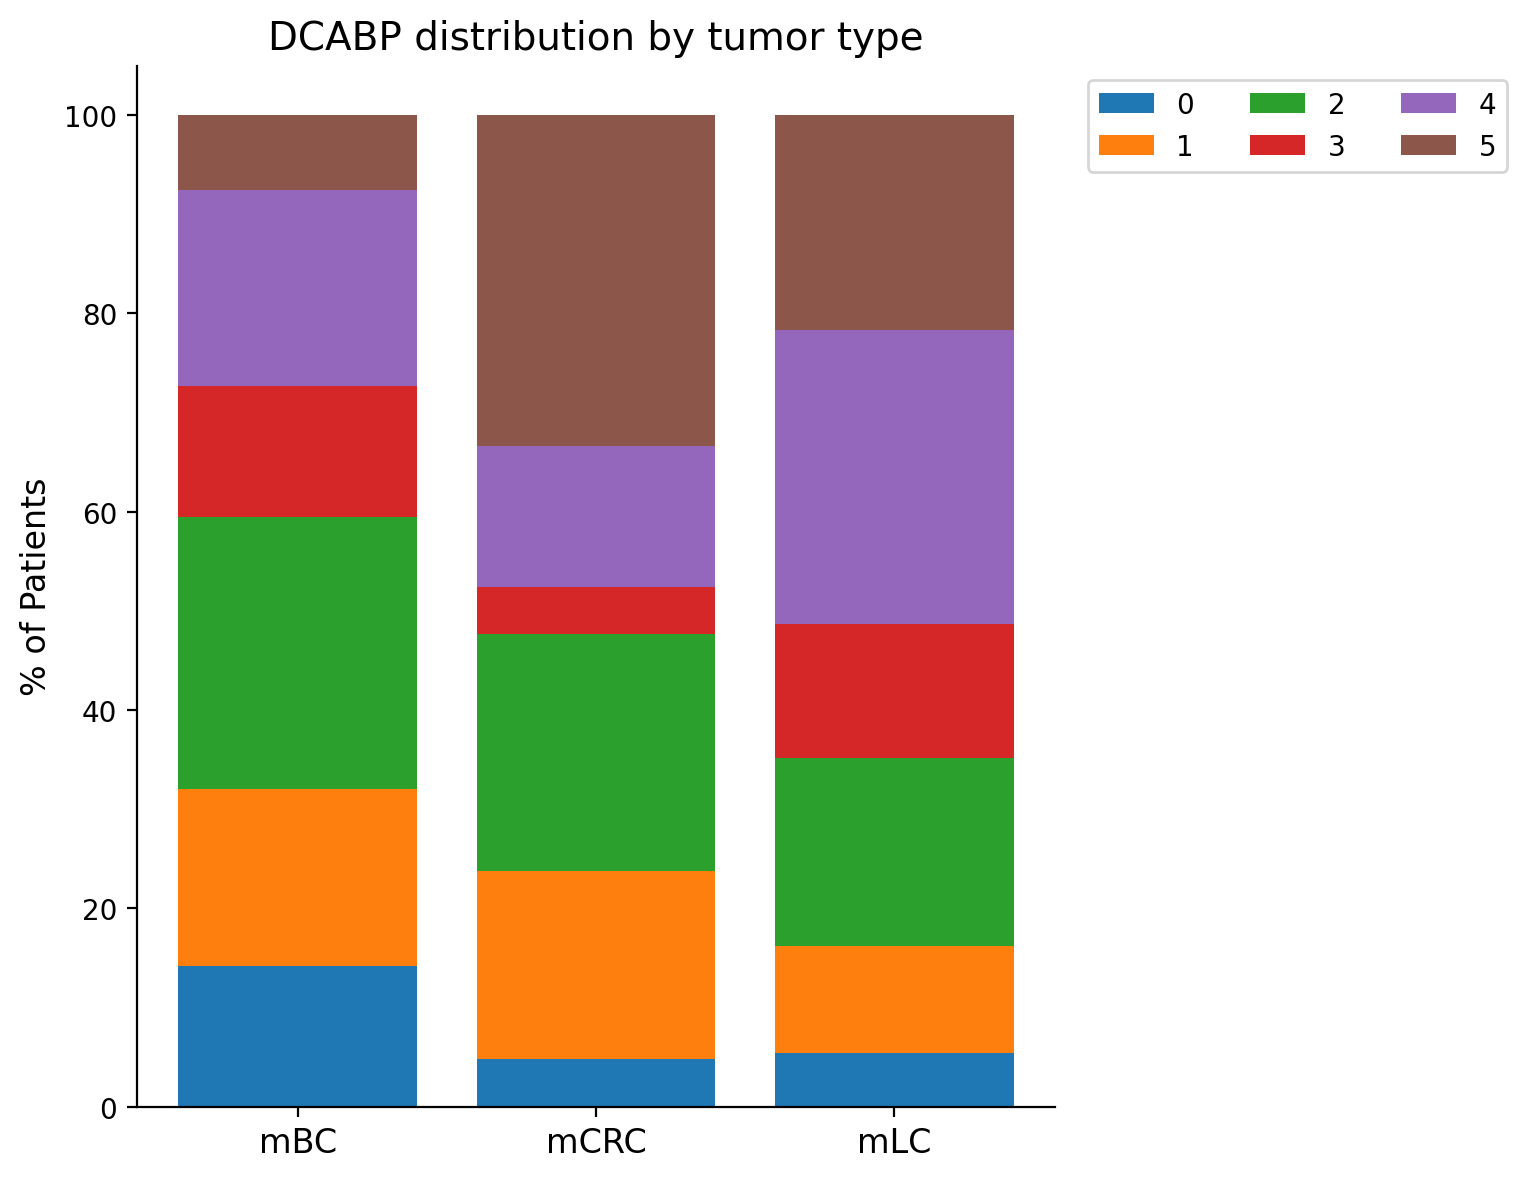

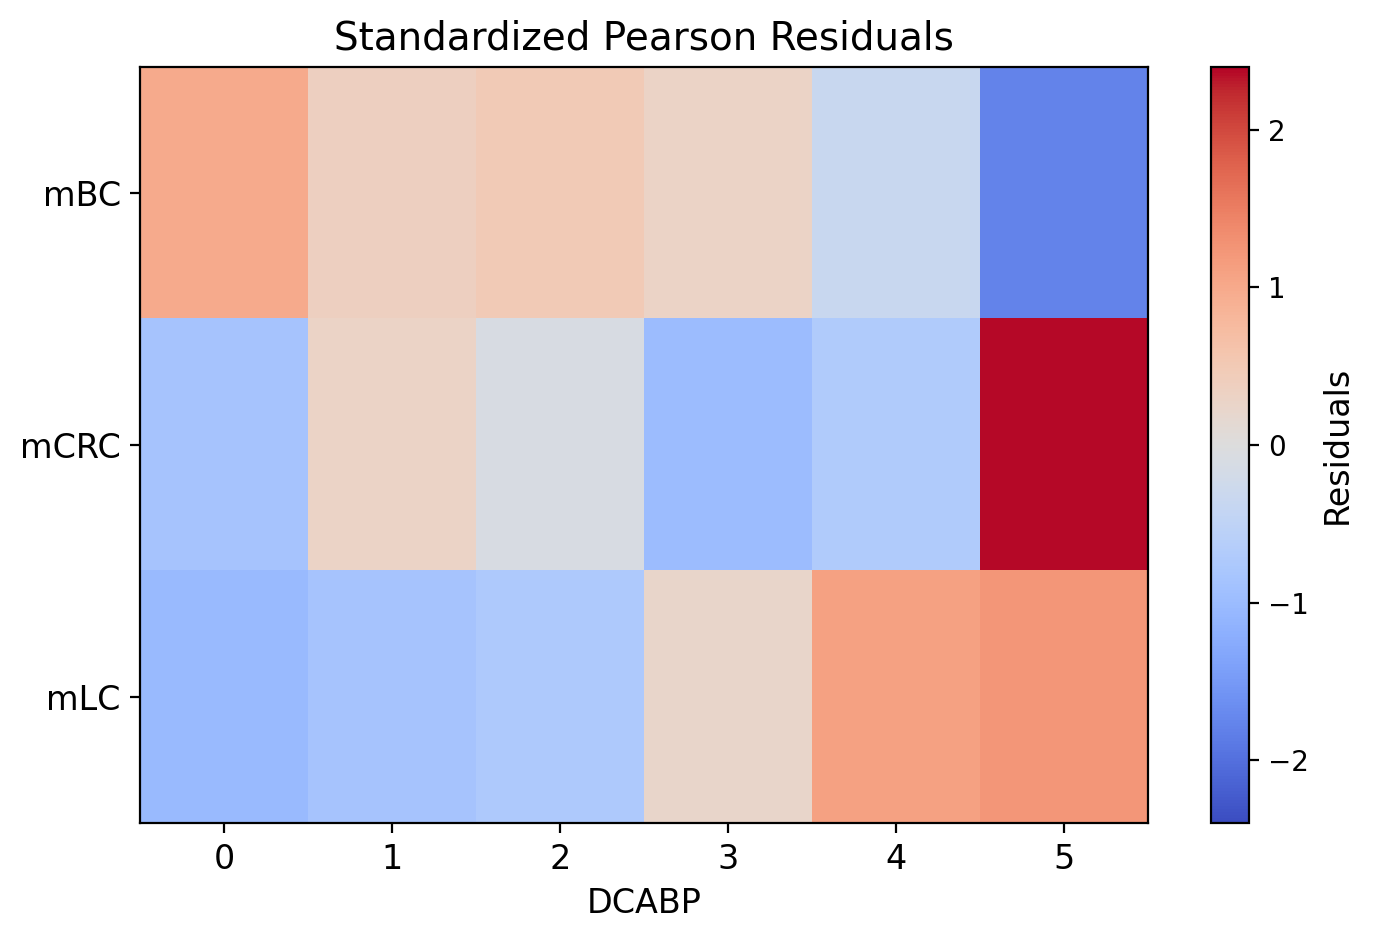

In [5]:
OUT_PREFIX = "Fig_TumorType_by_Topic"


tmp = df[[topic_col, 'Cohort']].copy()
tmp["tumor"] = tmp['Cohort']
tmp["topic"]   = clean_age_series(tmp[topic_col])
 
# Drop missing age or topic
n_total = len(tmp)
n_missing_topic = tmp["topic"].isna().sum()
n_missing_tumor = tmp["tumor"].isna().sum()
 
tmp2 = tmp.dropna(subset=["topic", "tumor"]).copy()
 
print(f"N total rows: {n_total}")
print(f"Missing topic: {n_missing_topic} | Missing age: {n_missing_age}")
print(f"N used for Tumor×Topic plots: {len(tmp2)}")
 

tumor_order = ["Breast", "Colorectal", "Lung"]
topic_levels = sorted(tmp2["topic"].unique())
 
# Contingency table
counts = pd.crosstab(tmp2["tumor"], tmp2["topic"]).reindex(index=tumor_order, columns=topic_levels, fill_value=0)
print("\nContingency table (counts):")
print(counts)
 
# -----------------------
# 1) Stacked bars (% within age tertile)
# -----------------------
props = counts.div(counts.sum(axis=1), axis=0) * 100
 
fig, ax = plt.subplots(figsize=(10, 6), dpi=200)
 
bottom = np.zeros(len(props))
x = np.arange(len(props.index))
 
for t in props.columns:
    vals = props[t].to_numpy()
    ax.bar(x, vals, bottom=bottom, label=str(int(t)) if float(t).is_integer() else str(t))
    bottom += vals
 
ax.set_xticks(x)
ax.set_xticklabels(["mBC", "mCRC", "mLC"], fontsize=12)
ax.set_ylabel("% of Patients", fontsize=12)
ax.set_title("DCABP distribution by tumor type", fontsize=14)
 
# Legend to the right (2 rows if you like)
ax.legend(
    ncol=3,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=True
)
sns.despine() 
plt.tight_layout(rect=[0, 0, 0.78, 1])
#fig.savefig(f"{OUT_PREFIX}_stackedbars.svg", bbox_inches="tight")
plt.show()
 
# -----------------------
# 2) Heatmap of standardized residuals (chi-square)
# -----------------------
chi2, p, dof, expected = chi2_contingency(counts.values)
 
resid = (counts.values - expected) / np.sqrt(expected)
max_abs = np.max(np.abs(resid))
vlim = max(1.0, float(np.ceil(max_abs*10)/10))
 
fig, ax = plt.subplots(figsize=(7.2, 4.8), dpi=200)
im = ax.imshow(resid, aspect="auto", vmin=-vlim, vmax=vlim, cmap="coolwarm")
 
ax.set_yticks(np.arange(len(counts.index)))
ax.set_yticklabels(["mBC", "mCRC", "mLC"], fontsize=12)
 
ax.set_xticks(np.arange(len(counts.columns)))
ax.set_xticklabels([str(int(c)) for c in counts.columns], ha="center", fontsize=12)
 
ax.set_title(f"Standardized Pearson Residuals", fontsize=14)
ax.set_xlabel(f"DCABP", fontsize=12)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Residuals", fontsize=12)
 
plt.tight_layout()
#fig.savefig(f"{OUT_PREFIX}_residuals_heatmap.svg", bbox_inches="tight")
plt.show()